In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

In [15]:
def evaluate_regression_model(y_true, y_pred, regr_type):
    evs = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("Evaluation Metrics for {} Regression Model".format(regr_type))
    print("Explained Variance Score: {}".format(round(evs, 4)))
    print("Mean Absolute Error: {}".format(round(mae, 4)))
    print("Mean Squared Error: {}".format(round(mse, 4)))
    print("Root Mean Squared Error: {}".format(round(np.sqrt(mse), 4)))
    print("R2 Score: {}".format(round(r2, 4)))
    print("")

In [4]:
noise=1
np.random.seed(42)
X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + noise*np.random.randn(1000, 1) 
y_ideal =  4 + 3 * X

y_outlier = pd.Series(y.reshape(-1).copy())

threshold = 1.5
outlier_indices = np.where(X.flatten() > threshold)[0]

num_outliers = 5
selected_indices = np.random.choice(outlier_indices, num_outliers, replace=False)

y_outlier[selected_indices] += np.random.uniform(50, 100, num_outliers)

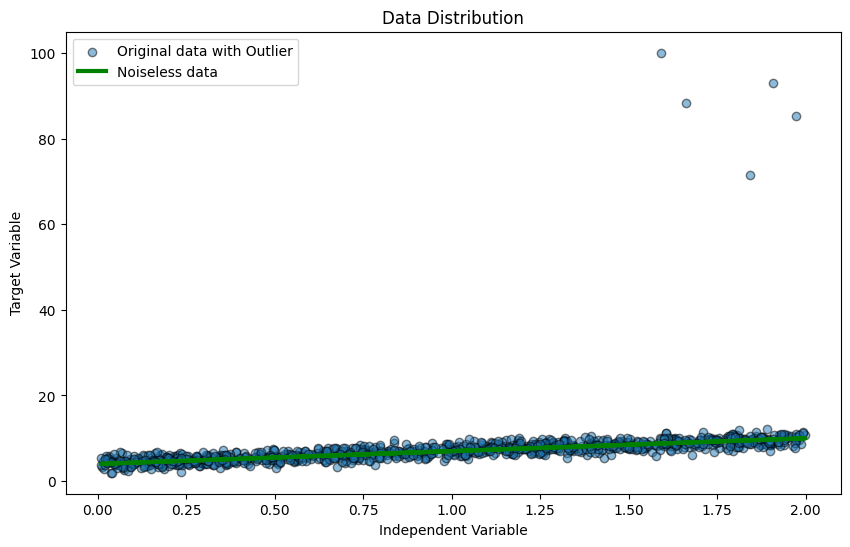

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(X, y_outlier, alpha=.5, ec="k", label="Original data with Outlier")
plt.plot(X, y_ideal, lw=3, c="g", label="Noiseless data")

plt.title("Data Distribution")
plt.ylabel("Target Variable")
plt.xlabel("feature Variable")
plt.legend()
plt.show()

In [21]:
linear = LinearRegression()
linear.fit(X,y_outlier)
lin_y = linear.predict(X)

ridge = Ridge(alpha=1)
ridge.fit(X,y_outlier)
rig_y = ridge.predict(X)

lasso = Lasso(alpha=.2)
lasso.fit(X,y_outlier)
las_y = lasso.predict(X)

evaluate_regression_model(y, lin_y, "Normal")
evaluate_regression_model(y, rig_y, "Ridge")
evaluate_regression_model(y, las_y, "Lasso")

Evaluation Metrics for Normal Regression Model
Explained Variance Score: 0.6748
Mean Absolute Error: 0.9468
Mean Squared Error: 1.4164
Root Mean Squared Error: 1.1901
R2 Score: 0.6357

Evaluation Metrics for Ridge Regression Model
Explained Variance Score: 0.6766
Mean Absolute Error: 0.9443
Mean Squared Error: 1.4094
Root Mean Squared Error: 1.1872
R2 Score: 0.6375

Evaluation Metrics for Lasso Regression Model
Explained Variance Score: 0.7394
Mean Absolute Error: 0.8597
Mean Squared Error: 1.1651
Root Mean Squared Error: 1.0794
R2 Score: 0.7003



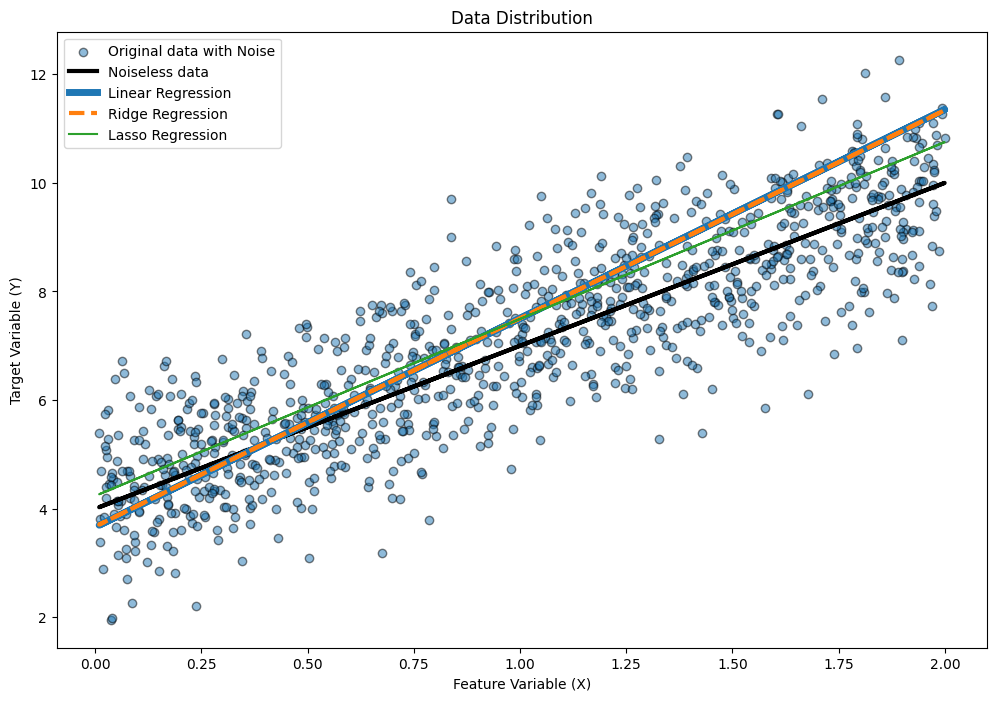

In [31]:
plt.figure(figsize=(12,8))

plt.scatter(X, y, alpha=.5, ec="k", label="Original data with Noise")
plt.plot(X, y_ideal, lw=3, c="k", label="Ideal, Noiseless data")
plt.plot(X, lin_y, linewidth=5, label="Linear Regression")
plt.plot(X, rig_y, linewidth=3, linestyle="--", label="Ridge Regression")
plt.plot(X, las_y, label="Lasso Regression")

plt.title("Data Distribution")
plt.ylabel("Target Variable (Y)")
plt.xlabel("Feature Variable (X)")
plt.legend()
plt.show()

In [32]:
linear = LinearRegression()
linear.fit(X,y)
lin_y1 = linear.predict(X)

ridge = Ridge(alpha=1)
ridge.fit(X,y)
rig_y1 = ridge.predict(X)

lasso = Lasso(alpha=.2)
lasso.fit(X,y)
las_y1 = lasso.predict(X)

evaluate_regression_model(y, lin_y1, "Normal")
evaluate_regression_model(y, rig_y1, "Ridge")
evaluate_regression_model(y, las_y1, "Lasso")

Evaluation Metrics for Normal Regression Model
Explained Variance Score: 0.7492
Mean Absolute Error: 0.7873
Mean Squared Error: 0.975
Root Mean Squared Error: 0.9874
R2 Score: 0.7492

Evaluation Metrics for Ridge Regression Model
Explained Variance Score: 0.7492
Mean Absolute Error: 0.7874
Mean Squared Error: 0.975
Root Mean Squared Error: 0.9874
R2 Score: 0.7492

Evaluation Metrics for Lasso Regression Model
Explained Variance Score: 0.7191
Mean Absolute Error: 0.8408
Mean Squared Error: 1.0923
Root Mean Squared Error: 1.0451
R2 Score: 0.7191



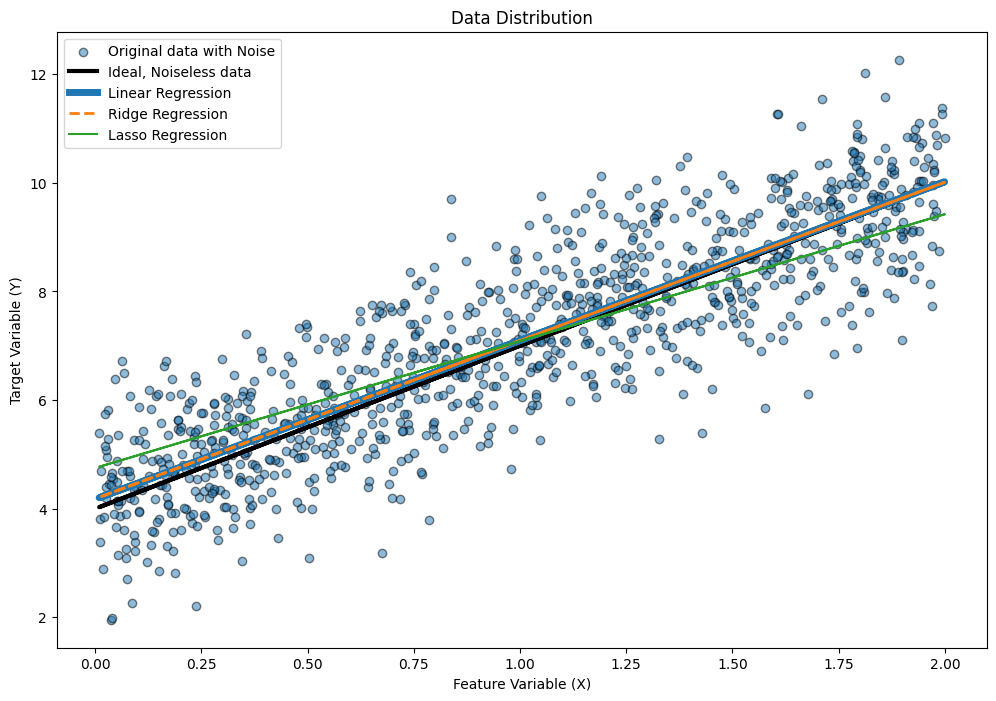

In [50]:
plt.figure(figsize=(12,8))

plt.scatter(X, y, alpha=.5, ec="k", label="Original data with Noise")
plt.plot(X, y_ideal, lw=3, c="k", label="Ideal, Noiseless data")
plt.plot(X, lin_y1, linewidth=5, label="Linear Regression")
plt.plot(X, rig_y1, linewidth=2, linestyle="--", label="Ridge Regression")
plt.plot(X, las_y1, label="Lasso Regression")

plt.title("Data Distribution")
plt.ylabel("Target Variable (Y)")
plt.xlabel("Feature Variable (X)")
plt.legend()
plt.show()

In [51]:
from sklearn.datasets import make_regression
make_regression()